# NOAA TAO/TRITON ENSO Data Exploration

This notebook explores ENSO related observations from the NOAA TAO/TRITON array, focusing on Sea Surface Temperature (SST) and 20°C Isotherm Depth (Z20). These variables are closely linked to the Recharge Oscillator framework, representing surface ocean conditions and upper-ocean heat content.

The objectives are to:

1. Read and preprocess NOAA observations.
2. Assess data quality, temporal coverage, and missing observations.
3. Construct Eastern and Western Pacific datasets.
4. Perform exploratory, statistical, and spectral analyses.
5. Prepare datasets for subsequent Recharge Oscillator and NGRC modelling.

# Data Description

The data were obtained from the NOAA TAO/TRITON moored buoy array.

**Source:**

https://www.pmel.noaa.gov/tao/drupal/disdel/

This study focuses on two ENSO related variables:

- Sea Surface Temperature (SST)
- 20°C Isotherm Depth (Z20)

The data are provided at **daily temporal resolution**, spanning **1 January 1979 to 15 June 2026**.

Two Pacific regions are considered in this study: the Eastern Pacific (Niño3) and Western Pacific (Niño4). Each region consists of nine sensors arranged on a 3×3 latitude-longitude grid.

### Eastern Pacific (Niño3)

| Latitude | 95°W | 110°W | 125°W |
|----------|------|-------|-------|
| 2°N | ✓ | ✓ | ✓ |
| 0° | ✓ | ✓ | ✓ |
| 2°S | ✓ | ✓ | ✓ |

### Western Pacific (Niño4)

| Latitude | 165°E | 170°W | 180° |
|----------|-------|-------|------|
| 2°N | ✓ | ✓ | ✓ |
| 0° | ✓ | ✓ | ✓ |
| 2°S | ✓ | ✓ | ✓ |


The following figure highlights the Niño3 and Niño4 regions used in this study.

![Niño Regions](../assets/nino-regions.png)

In [1]:
# Imports

from pathlib import Path
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from functools import reduce

from scipy.signal import periodogram, find_peaks

In [2]:
# Output directories

DATA = Path("../data")

OUTPUT_DIR = Path("../outputs")

IMAGE_DIR = OUTPUT_DIR / "images" / "enso"
LOG_DIR = OUTPUT_DIR / "logs" / "enso"

LOG_FILE = LOG_DIR / "analysis_report.txt"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def clean_file(filename, variable_name="sst"):

    records = []

    with gzip.open(filename, "rt") as f:
        for line in f:
            parts = line.split()

            try:

                if len(parts) >= 5:
                    records.append([parts[0], parts[1], float(parts[2]), int(parts[3]), int(parts[4])])

                elif len(parts) == 4:
                    records.append([parts[0], parts[1], float(parts[2]), int(parts[3]), np.nan])

            except ValueError:
                pass

    df = pd.DataFrame(records, columns=["date", "time", variable_name, "quality", "source"])

    df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

    total = len(df)
    missing = (df[variable_name] == -9.99).sum()

    df[variable_name] = df[variable_name].replace(-9.99, np.nan)

    print(f"File      : {Path(filename).name}")
    print(f"Records   : {total}")
    print(f"Missing   : {missing}")
    print(f"Available : {total-missing}")
    print(f"Date      : {df['date'].min()} → {df['date'].max()}")
    print("=" * 80)

    return df

### Western Pacific SST (Niño4)

In [4]:
path = DATA / "daily/NINO4_SST/*.gz"

west_sst_dfs = []

for file in glob(str(path)):
    sensor = Path(file).name.replace("_dy.ascii.gz", "")

    df = clean_file(file)[["date", "sst"]]

    df = df.rename(columns={"sst": sensor})

    west_sst_dfs.append(df)

File      : sst0n180w_dy.ascii.gz
Records   : 9319
Missing   : 32
Available : 9287
Date      : 1993-03-27 00:00:00 → 2026-06-17 00:00:00
File      : sst0n165e_dy.ascii.gz
Records   : 11284
Missing   : 26
Available : 11258
Date      : 1986-12-13 00:00:00 → 2026-06-17 00:00:00
File      : sst2n170w_dy.ascii.gz
Records   : 9740
Missing   : 22
Available : 9718
Date      : 1992-03-06 00:00:00 → 2026-06-17 00:00:00
File      : sst2s170w_dy.ascii.gz
Records   : 9565
Missing   : 30
Available : 9535
Date      : 1992-03-10 00:00:00 → 2026-06-17 00:00:00
File      : sst2n180w_dy.ascii.gz
Records   : 10057
Missing   : 19
Available : 10038
Date      : 1993-03-28 00:00:00 → 2026-06-17 00:00:00
File      : sst2n165e_dy.ascii.gz
Records   : 10582
Missing   : 31
Available : 10551
Date      : 1985-07-09 00:00:00 → 2026-06-17 00:00:00
File      : sst0n170w_dy.ascii.gz
Records   : 11382
Missing   : 59
Available : 11323
Date      : 1988-05-16 00:00:00 → 2026-06-17 00:00:00
File      : sst2s165e_dy.ascii.gz

In [5]:
west_sst_df = reduce(
    lambda l, r: pd.merge(l, r, on="date", how="outer"),
    west_sst_dfs
)

west_sst_df = west_sst_df.sort_values("date").reset_index(drop=True)

west_sst_df["sst_mean"] = west_sst_df.drop(columns="date").mean(axis=1)

print(west_sst_df.shape)

west_sst_df.head()

(14625, 11)


,date,sst0n180w,sst0n165e,sst2n170w,sst2s170w,sst2n180w,sst2n165e,sst0n170w,sst2s165e,sst2s180w,sst_mean
0,1985-07-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.32,NaN,29.320
1,1985-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.32,NaN,29.320
2,1985-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1985-07-09,NaN,NaN,NaN,NaN,NaN,29.12,NaN,29.25,NaN,29.185
4,1985-07-10,NaN,NaN,NaN,NaN,NaN,29.79,NaN,29.38,NaN,29.585


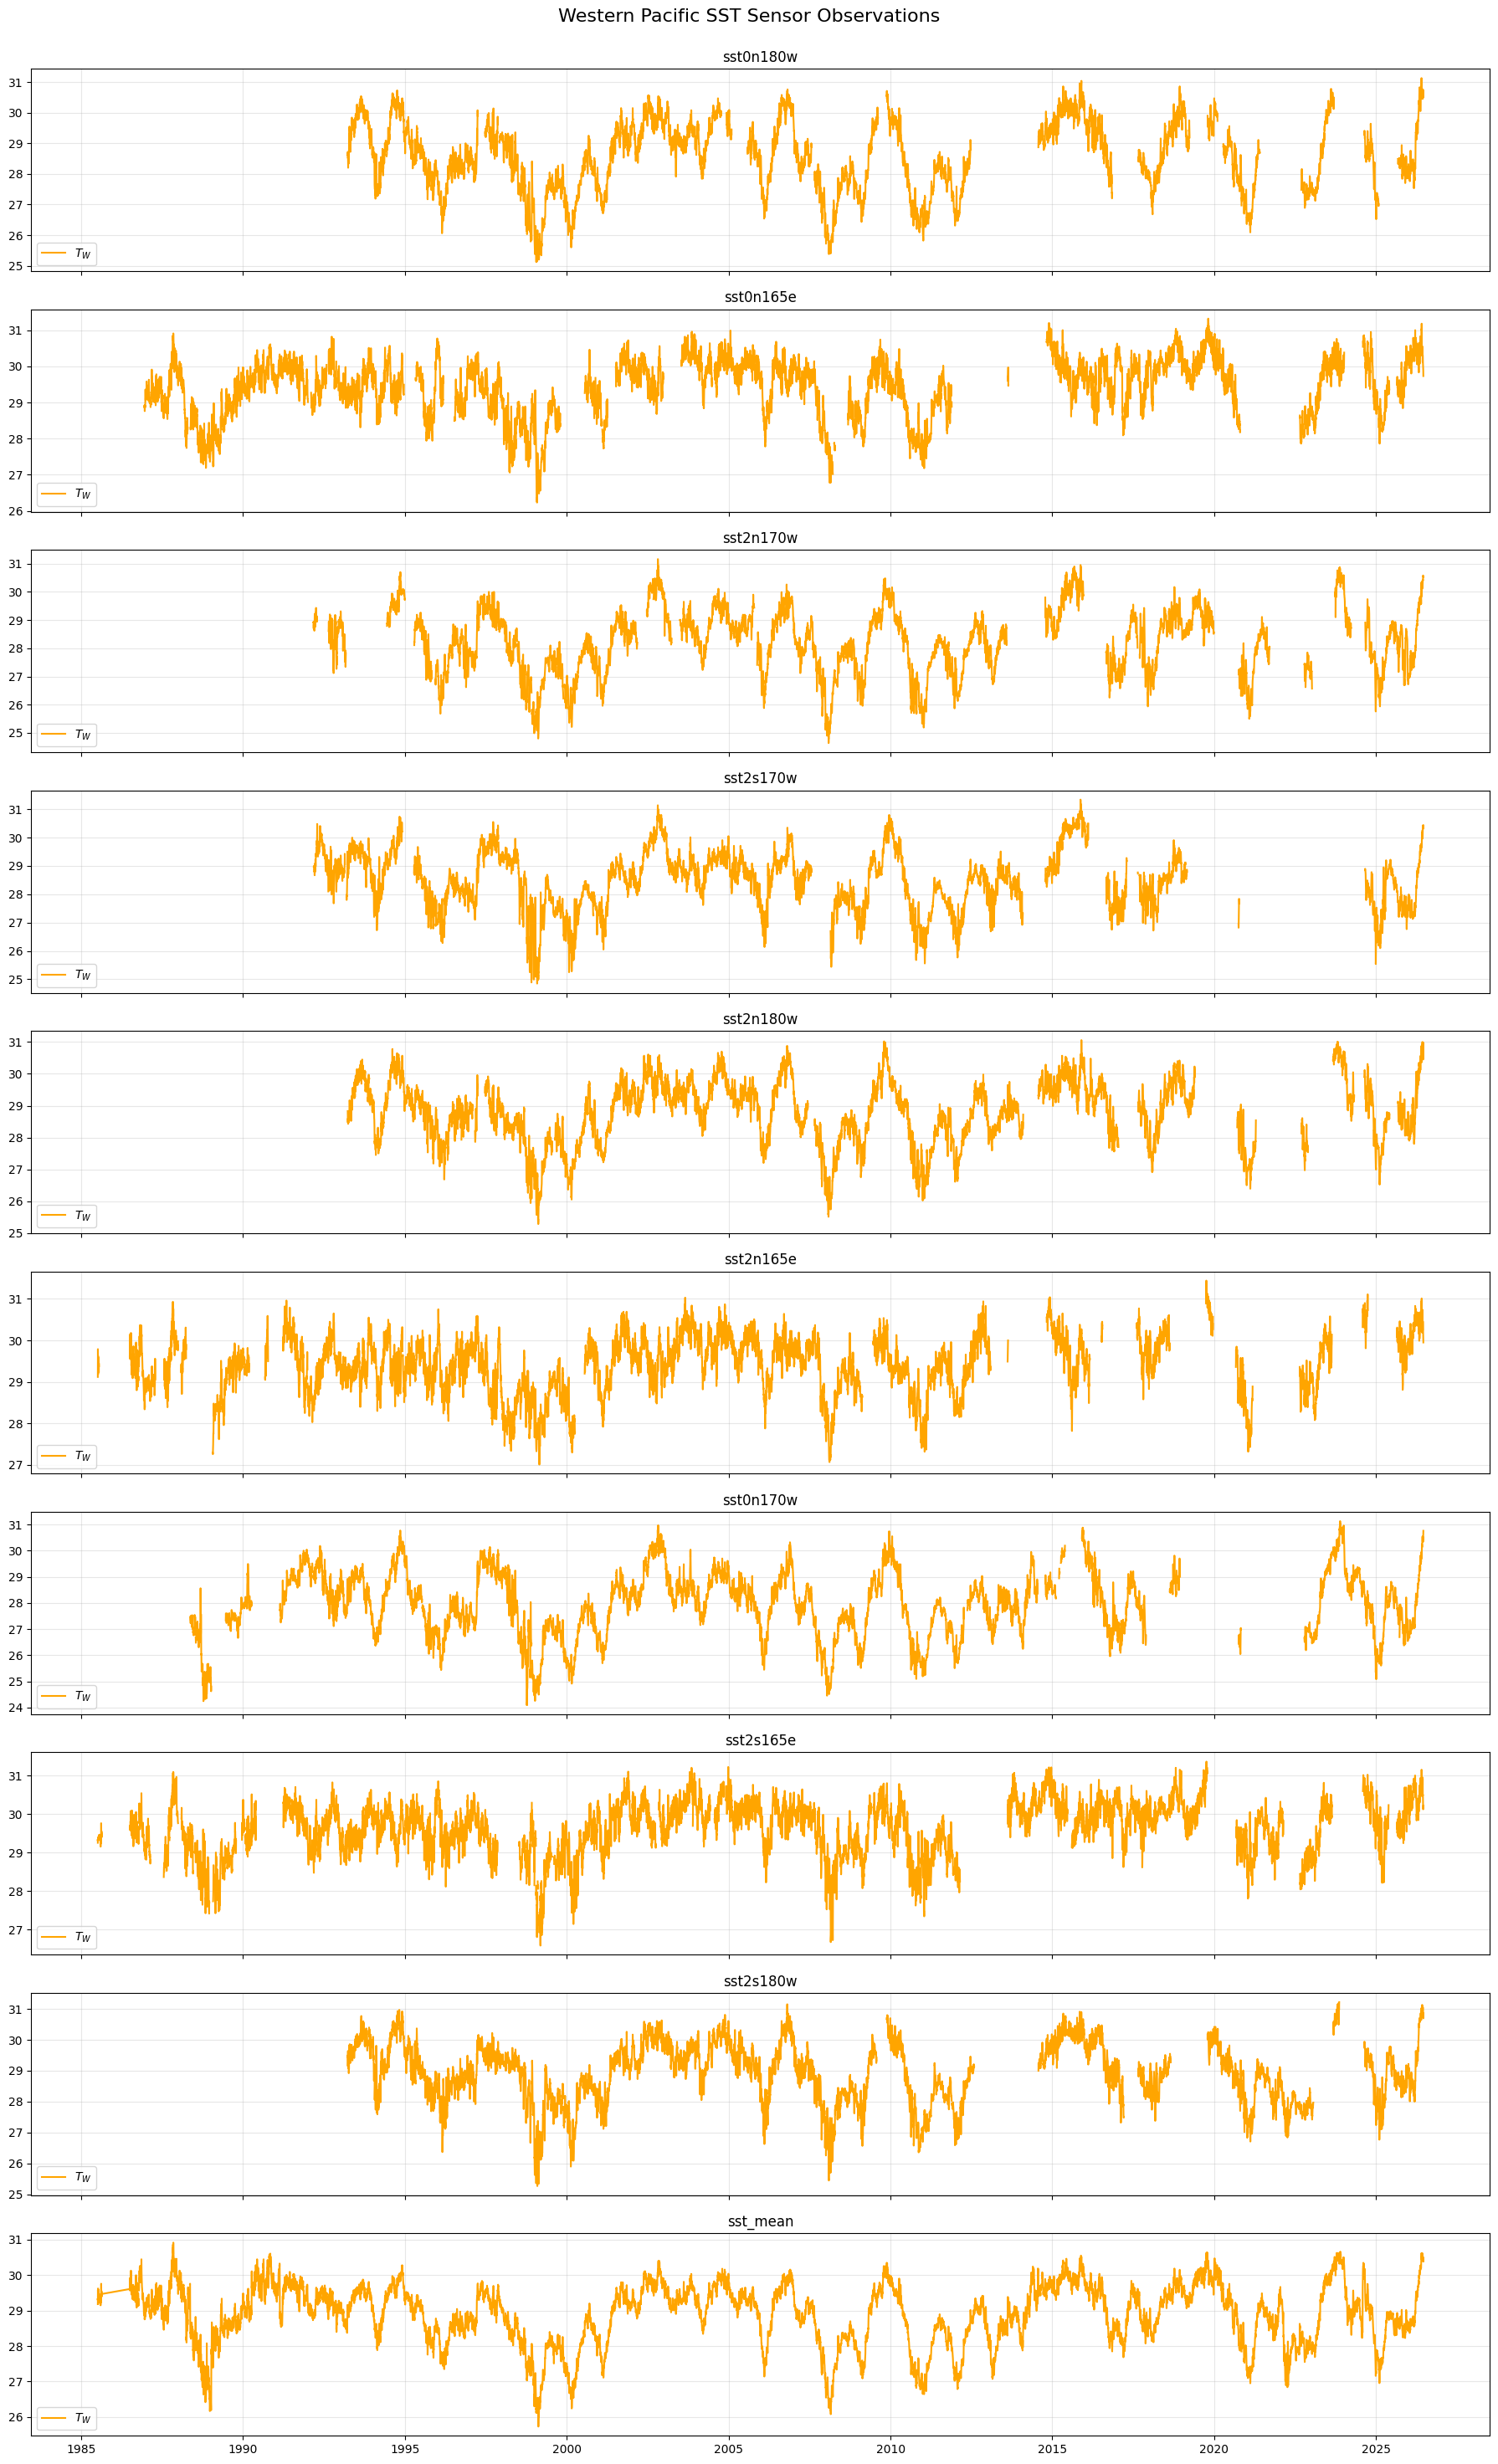

In [6]:
fig, axes = plt.subplots(
    len(west_sst_df.columns)-1, 1,
    figsize=(18, 3*(len(west_sst_df.columns)-1)),
    sharex=True
)

for ax, col in zip(axes, west_sst_df.columns[1:]):

    ax.plot(
        west_sst_df["date"],
        west_sst_df[col],
        color="orange",
        label=r"$T_W$"
    )

    ax.set_title(col)

    ax.legend(loc="lower left")

    ax.grid(alpha=0.3)

fig.suptitle(
    "Western Pacific SST Sensor Observations",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig(
    IMAGE_DIR / "west_sst_sensors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

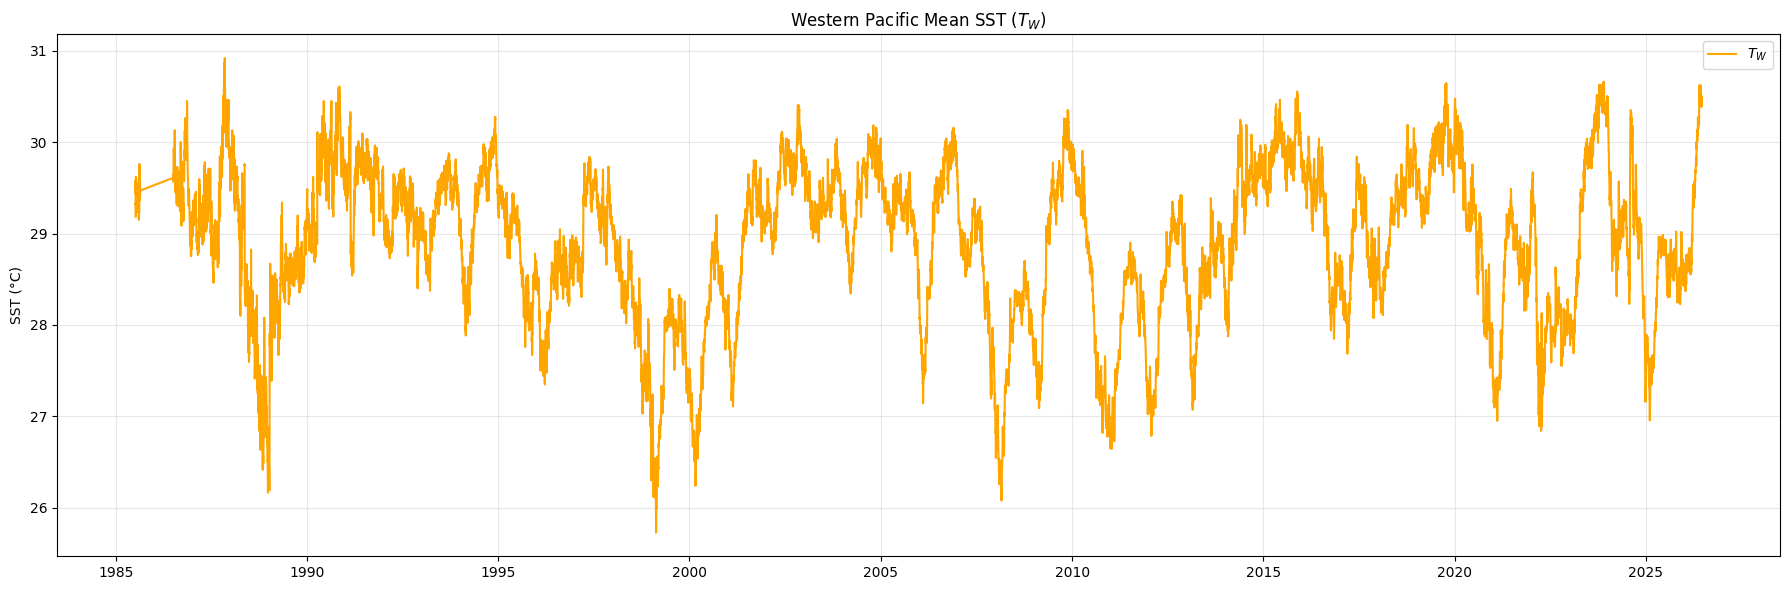

In [7]:
plt.figure(figsize=(18, 6))

plt.plot(
    west_sst_df["date"],
    west_sst_df["sst_mean"],
    color="orange",
    linewidth=1.5,
    label=r"$T_W$"
)

plt.title(r"Western Pacific Mean SST ($T_W$)")
plt.ylabel("SST (°C)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "west_sst_mean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Eastern Pacific SST (Niño3)

In [8]:
path = DATA / "daily/NINO3_SST/*.gz"

east_sst_dfs = []

for file in glob(str(path)):
    sensor = Path(file).name.replace("_dy.ascii.gz", "")

    df = clean_file(file)[["date", "sst"]]

    df = df.rename(columns={"sst": sensor})

    east_sst_dfs.append(df)

File      : sst0n110w_dy.ascii.gz
Records   : 12679
Missing   : 37
Available : 12642
Date      : 1980-03-07 00:00:00 → 2026-06-17 00:00:00
File      : sst0.7s110w_dy.ascii.gz
Records   : 564
Missing   : 0
Available : 564
Date      : 1979-01-20 00:00:00 → 1981-07-11 00:00:00
File      : sst0.7n110w_dy.ascii.gz
Records   : 677
Missing   : 2
Available : 675
Date      : 1979-01-20 00:00:00 → 1981-10-30 00:00:00
File      : sst2n125w_dy.ascii.gz
Records   : 8924
Missing   : 52
Available : 8872
Date      : 1991-12-06 00:00:00 → 2026-06-17 00:00:00
File      : sst0n95w_dy.ascii.gz
Records   : 8779
Missing   : 44
Available : 8735
Date      : 1981-07-05 00:00:00 → 2026-06-17 00:00:00
File      : sst2s95w_dy.ascii.gz
Records   : 8870
Missing   : 68
Available : 8802
Date      : 1992-11-14 00:00:00 → 2026-06-17 00:00:00
File      : sst2s125w_dy.ascii.gz
Records   : 9561
Missing   : 55
Available : 9506
Date      : 1991-11-05 00:00:00 → 2026-06-17 00:00:00
File      : sst0n110.5w_dy.ascii.gz
Records

In [9]:
east_sst_df = reduce(
    lambda l, r: pd.merge(l, r, on="date", how="outer"),
    east_sst_dfs
)

east_sst_df = east_sst_df.sort_values("date").reset_index(drop=True)

east_sst_df["sst_mean"] = east_sst_df.drop(columns="date").mean(axis=1)

print(east_sst_df.shape)

east_sst_df.head()

(16536, 14)


,date,sst0n110w,sst0.7s110w,sst0.7n110w,sst2n125w,sst0n95w,sst2s95w,sst2s125w,sst0n110.5w,sst2n110w,sst2n95w,sst2s110w,sst0n125w,sst_mean
0,1979-01-20,NaN,23.88,23.74,NaN,NaN,NaN,NaN,23.76,NaN,NaN,NaN,NaN,23.793333
1,1979-01-21,NaN,24.08,23.75,NaN,NaN,NaN,NaN,23.98,NaN,NaN,NaN,NaN,23.936667
2,1979-01-22,NaN,24.15,23.92,NaN,NaN,NaN,NaN,24.10,NaN,NaN,NaN,NaN,24.056667
3,1979-01-23,NaN,23.62,23.84,NaN,NaN,NaN,NaN,23.97,NaN,NaN,NaN,NaN,23.810000
4,1979-01-24,NaN,24.17,23.82,NaN,NaN,NaN,NaN,24.02,NaN,NaN,NaN,NaN,24.003333


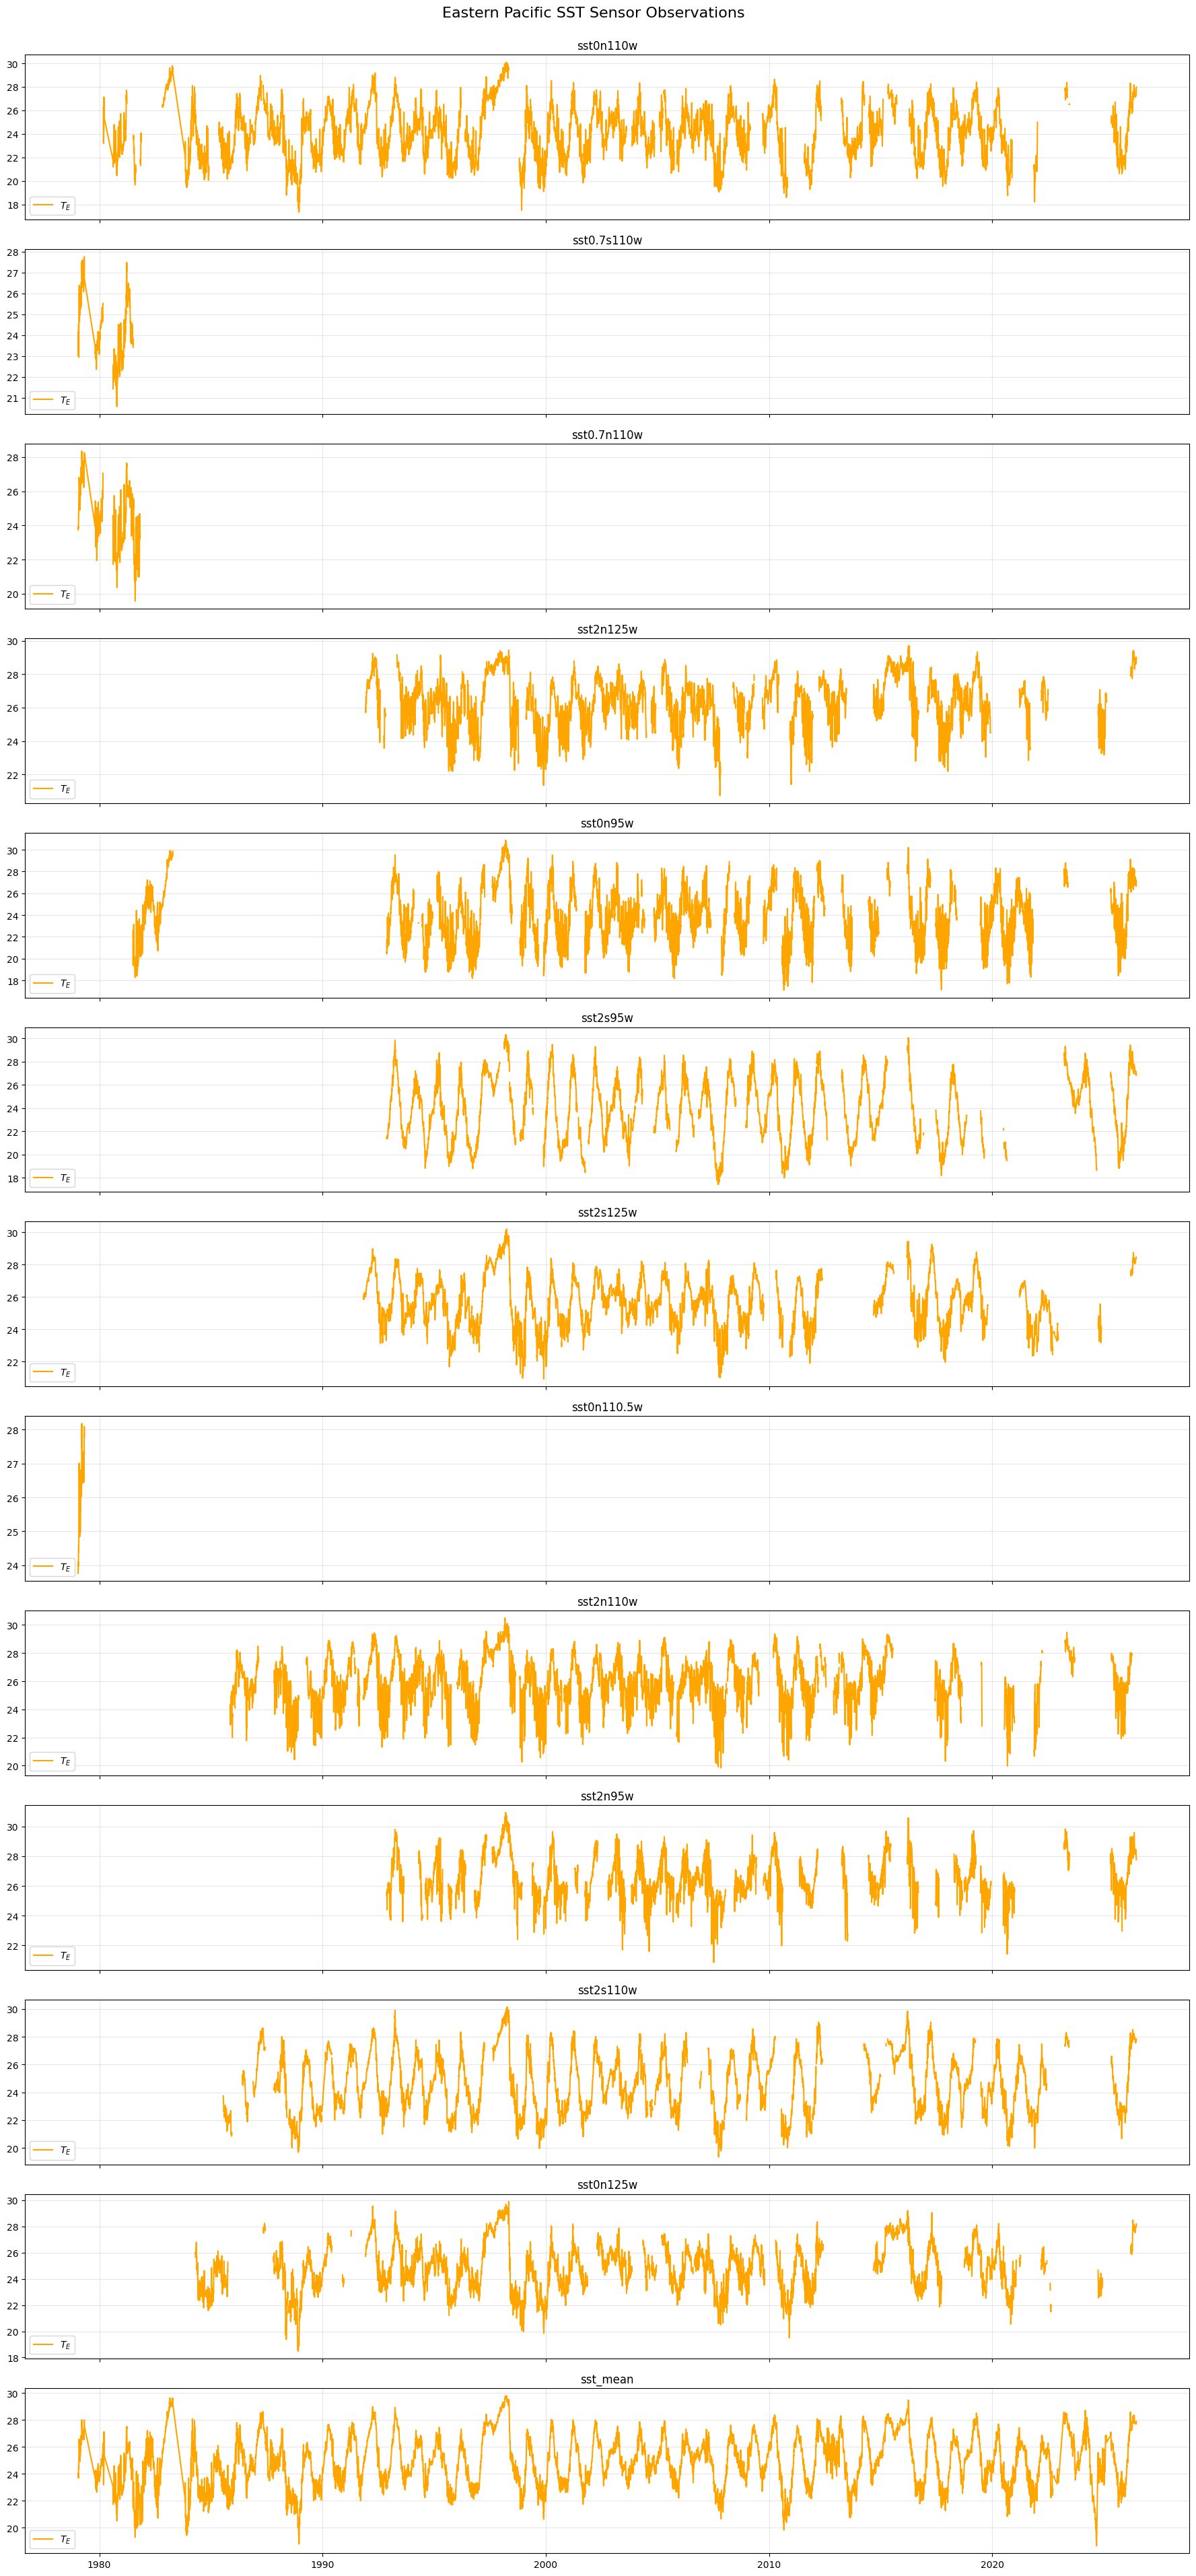

In [10]:
fig, axes = plt.subplots(
    len(east_sst_df.columns)-1, 1,
    figsize=(18, 3*(len(east_sst_df.columns)-1)),
    sharex=True
)

for ax, col in zip(axes, east_sst_df.columns[1:]):

    ax.plot(
        east_sst_df["date"],
        east_sst_df[col],
        color="orange",
        label=r"$T_E$"
    )

    ax.set_title(col)

    ax.legend(loc="lower left")

    ax.grid(alpha=0.3)

fig.suptitle(
    "Eastern Pacific SST Sensor Observations",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig(
    IMAGE_DIR / "east_sst_sensors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

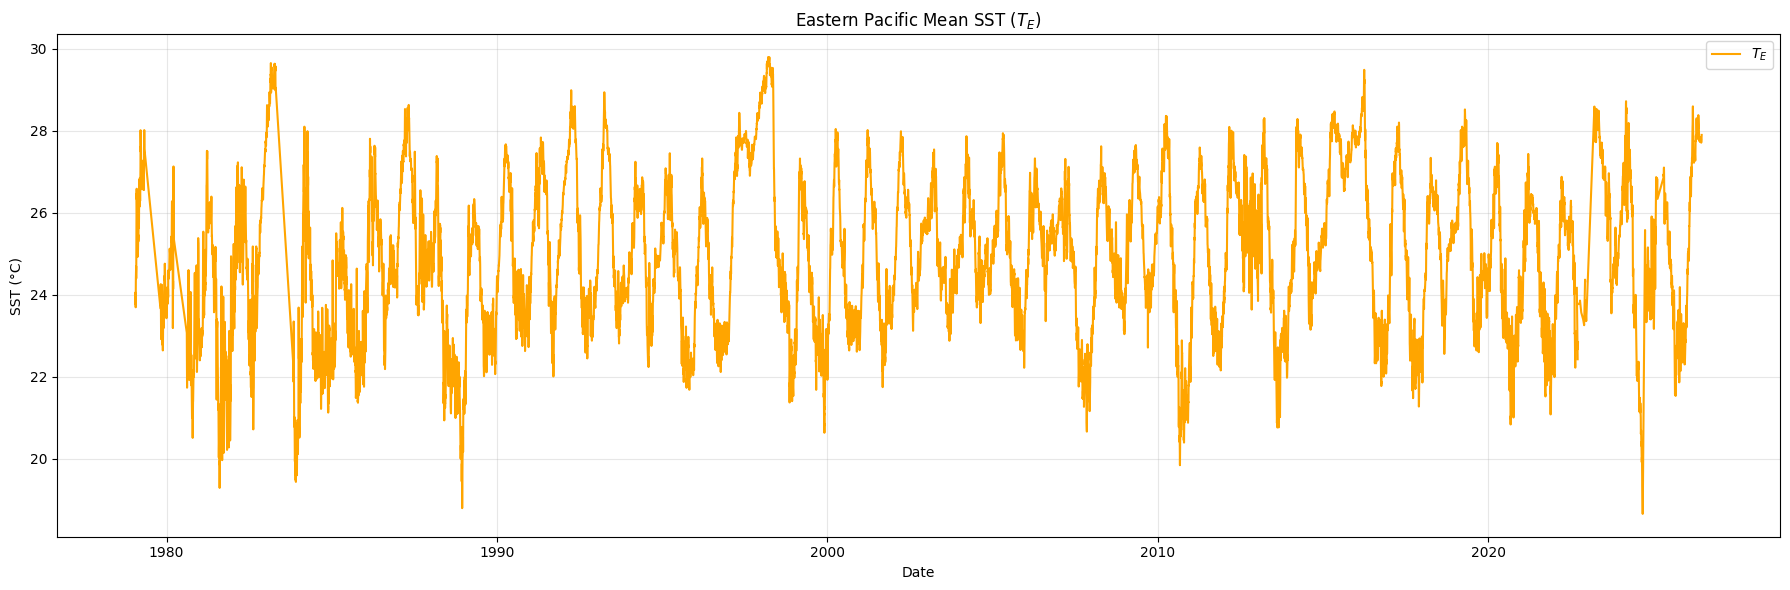

In [11]:
plt.figure(figsize=(18, 6))

plt.plot(
    east_sst_df["date"],
    east_sst_df["sst_mean"],
    color="orange",
    linewidth=1.5,
    label=r"$T_E$"
)

plt.title(r"Eastern Pacific Mean SST ($T_E$)")
plt.xlabel("Date")
plt.ylabel("SST (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "east_sst_mean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Z20 Isotherm Depth

In [12]:
path = DATA / "daily/NINO3_Z20/*.gz"

east_h_dfs = []

for file in glob(str(path)):

    sensor = Path(file).name.replace("_dy.ascii.gz", "")

    df = clean_file(file, variable_name="z20")[["date", "z20"]]

    df = df.rename(columns={"z20": sensor})

    east_h_dfs.append(df)

File      : iso2n125w_dy.ascii.gz
Records   : 9705
Missing   : 151
Available : 9554
Date      : 1991-12-06 00:00:00 → 2026-06-17 00:00:00
File      : iso2s125w_dy.ascii.gz
Records   : 10794
Missing   : 198
Available : 10596
Date      : 1992-09-27 00:00:00 → 2026-06-17 00:00:00
File      : iso0n110w_dy.ascii.gz
Records   : 12826
Missing   : 304
Available : 12522
Date      : 1980-03-07 00:00:00 → 2026-06-17 00:00:00
File      : iso0n110.5w_dy.ascii.gz
Records   : 103
Missing   : 0
Available : 103
Date      : 1979-01-20 00:00:00 → 1979-05-02 00:00:00
File      : iso2s95w_dy.ascii.gz
Records   : 8577
Missing   : 224
Available : 8353
Date      : 1993-07-24 00:00:00 → 2026-06-17 00:00:00
File      : iso0n95w_dy.ascii.gz
Records   : 7809
Missing   : 438
Available : 7371
Date      : 1981-07-05 00:00:00 → 2026-06-17 00:00:00
File      : iso0n125w_dy.ascii.gz
Records   : 10218
Missing   : 297
Available : 9921
Date      : 1983-10-30 00:00:00 → 2026-06-17 00:00:00
File      : iso2n95w_dy.ascii.gz


In [13]:
east_h_df = reduce(
    lambda l, r: pd.merge(l, r, on="date", how="outer"),
    east_h_dfs
)

east_h_df = east_h_df.sort_values("date").reset_index(drop=True)

east_h_df["z20_mean"] = east_h_df.drop(columns="date").mean(axis=1)

print(east_h_df.shape)

east_h_df.head()

(17055, 14)


,date,iso2n125w,iso2s125w,iso0n110w,iso0n110.5w,iso2s95w,iso0n95w,iso0n125w,iso2n95w,iso2n110w,iso0.7n110w,iso2s110w,iso0.7s110w,z20_mean
0,1979-01-20,NaN,NaN,NaN,68.81,NaN,NaN,NaN,NaN,NaN,64.84,NaN,76.76,70.136667
1,1979-01-21,NaN,NaN,NaN,63.89,NaN,NaN,NaN,NaN,NaN,57.74,NaN,75.57,65.733333
2,1979-01-22,NaN,NaN,NaN,68.73,NaN,NaN,NaN,NaN,NaN,53.75,NaN,68.27,63.583333
3,1979-01-23,NaN,NaN,NaN,63.17,NaN,NaN,NaN,NaN,NaN,54.94,NaN,68.40,62.170000
4,1979-01-24,NaN,NaN,NaN,69.26,NaN,NaN,NaN,NaN,NaN,63.79,NaN,70.46,67.836667


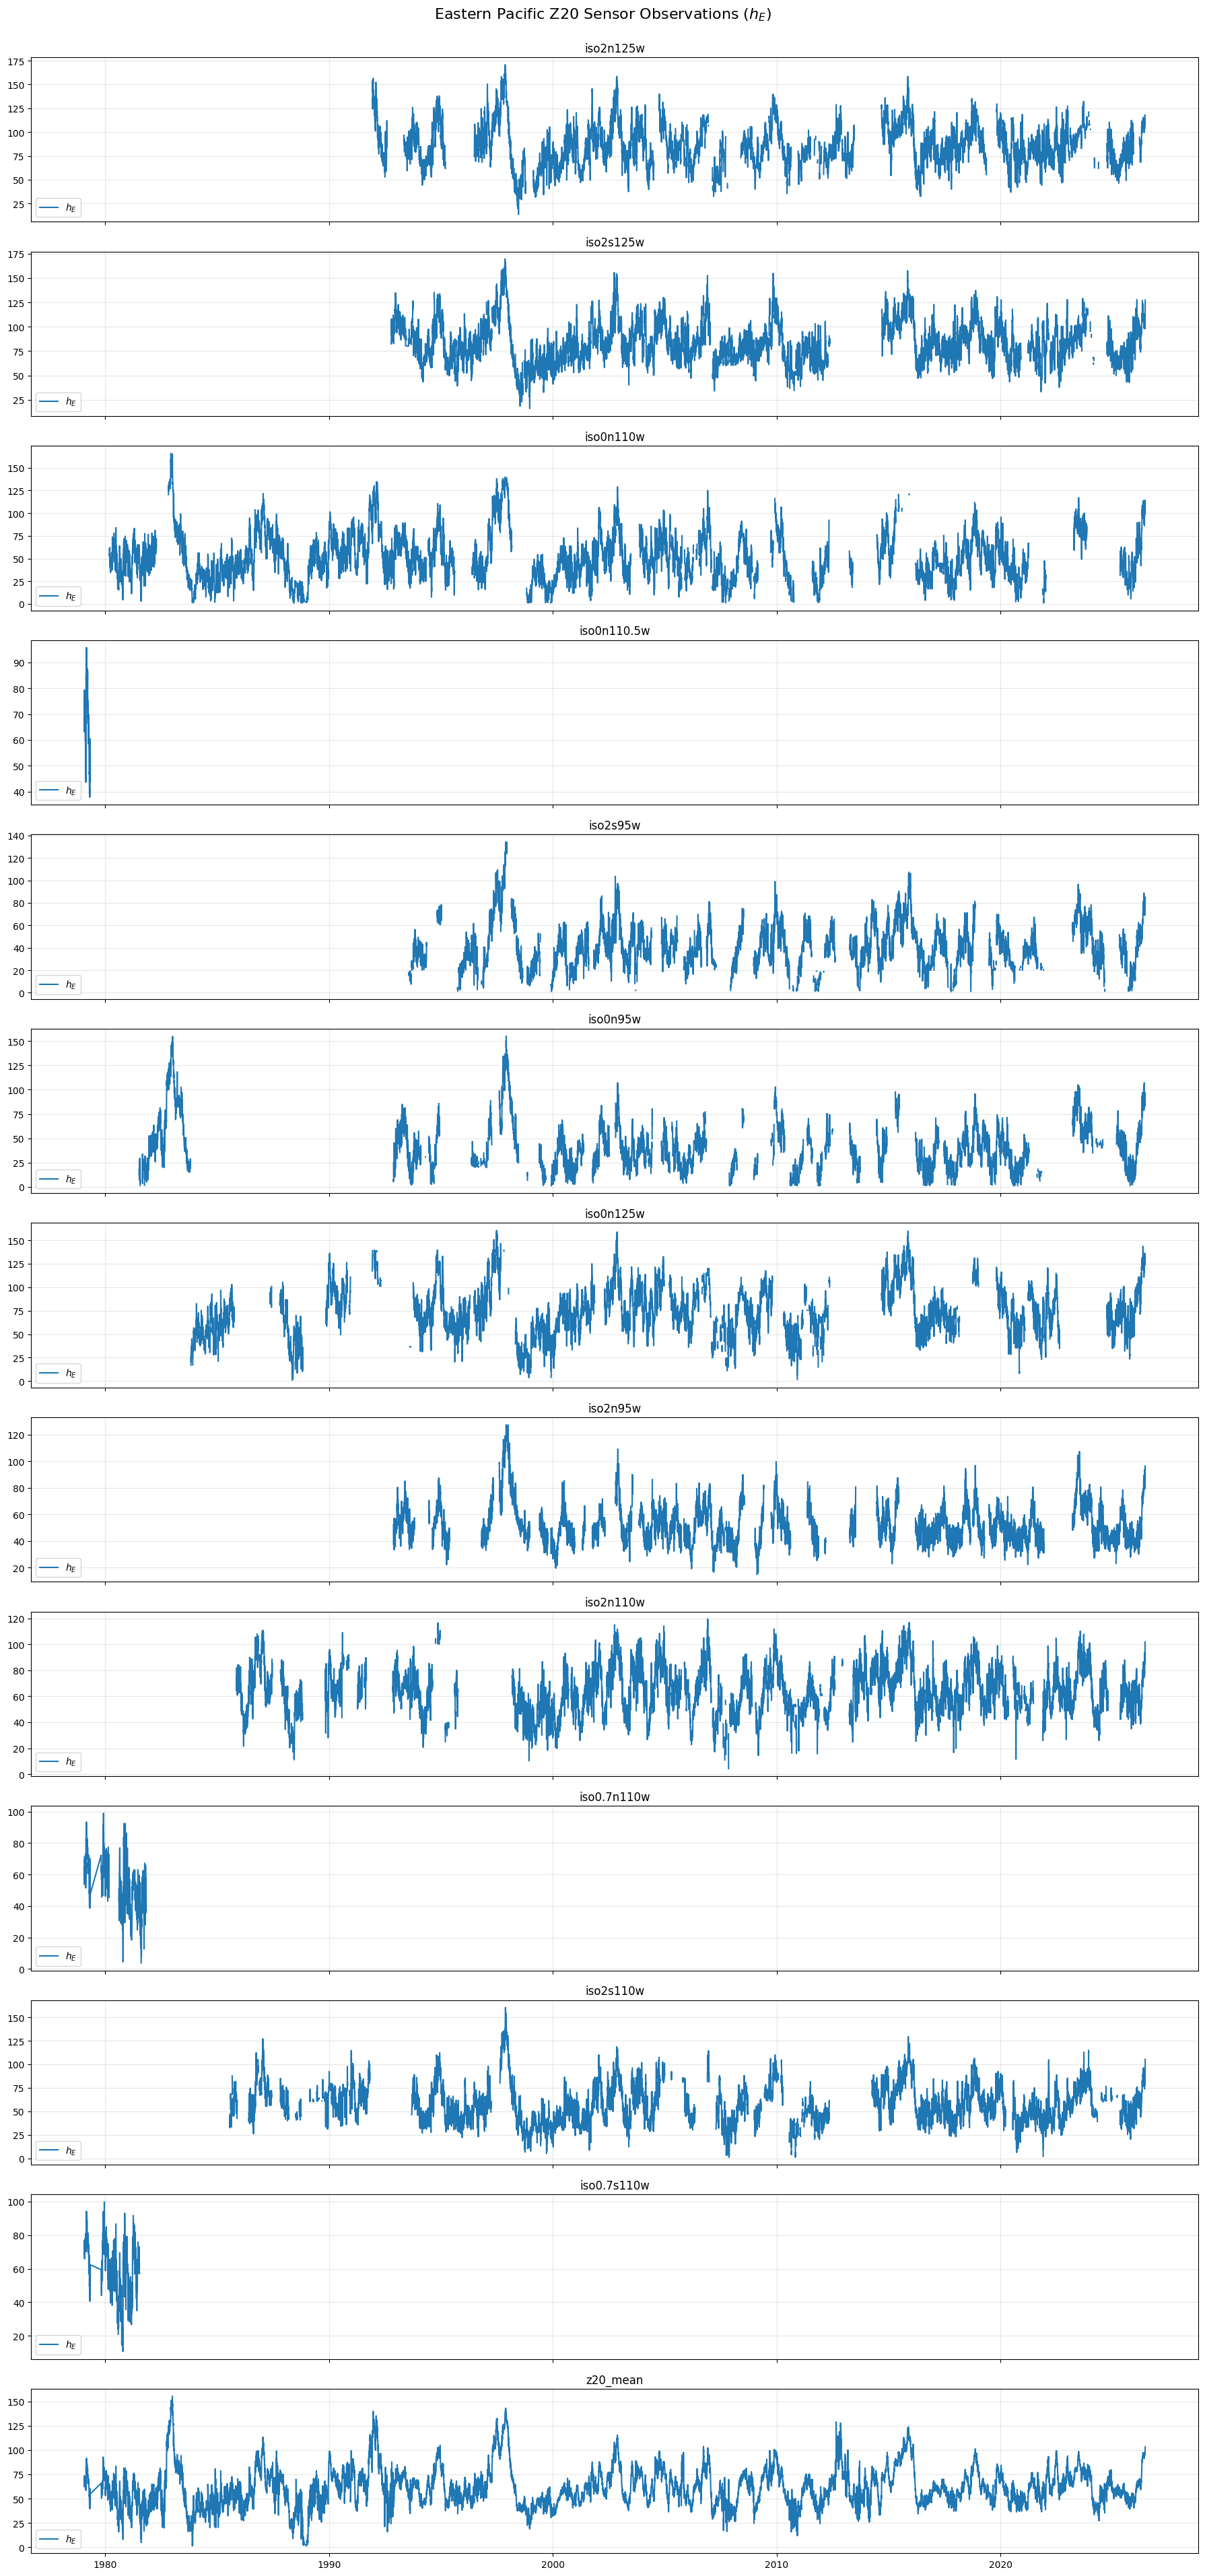

In [14]:
fig, axes = plt.subplots(
    len(east_h_df.columns)-1, 1,
    figsize=(18, 3*(len(east_h_df.columns)-1)),
    sharex=True
)

for ax, col in zip(axes, east_h_df.columns[1:]):

    ax.plot(
        east_h_df["date"],
        east_h_df[col],
        color="tab:blue",
        label=r"$h_E$"
    )

    ax.set_title(col)

    ax.legend(loc="lower left")

    ax.grid(alpha=0.3)

fig.suptitle(
    r"Eastern Pacific Z20 Sensor Observations ($h_E$)",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig(
    IMAGE_DIR / "east_h_sensors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

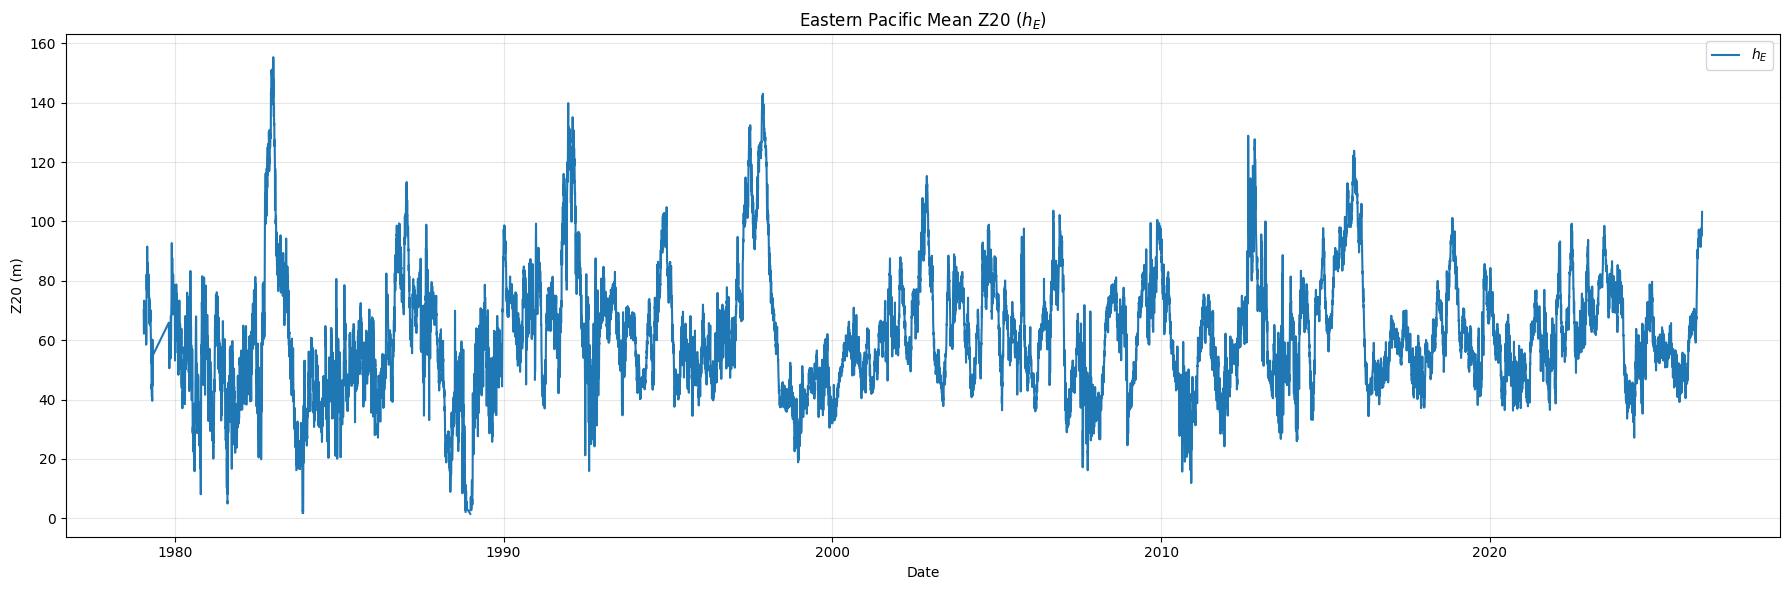

In [15]:
plt.figure(figsize=(18, 6))

plt.plot(
    east_h_df["date"],
    east_h_df["z20_mean"],
    color="tab:blue",
    linewidth=1.5,
    label=r"$h_E$"
)

plt.title(r"Eastern Pacific Mean Z20 ($h_E$)")
plt.xlabel("Date")
plt.ylabel("Z20 (m)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "east_h_mean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Western Pacific Z20 (Niño4)

In [16]:
path = DATA / "daily/NINO4_Z20/*.gz"

west_h_dfs = []

for file in glob(str(path)):

    sensor = Path(file).name.replace("_dy.ascii.gz", "")

    df = clean_file(file, variable_name="z20")[["date", "z20"]]

    df = df.rename(columns={"z20": sensor})

    west_h_dfs.append(df)

File      : iso0n180w_dy.ascii.gz
Records   : 9836
Missing   : 124
Available : 9712
Date      : 1993-04-10 00:00:00 → 2026-06-16 00:00:00
File      : iso2n170w_dy.ascii.gz
Records   : 11247
Missing   : 89
Available : 11158
Date      : 1992-03-06 00:00:00 → 2026-06-17 00:00:00
File      : iso0n165e_dy.ascii.gz
Records   : 11685
Missing   : 113
Available : 11572
Date      : 1986-01-20 00:00:00 → 2026-06-16 00:00:00
File      : iso2s170w_dy.ascii.gz
Records   : 10040
Missing   : 146
Available : 9894
Date      : 1992-03-10 00:00:00 → 2026-06-16 00:00:00
File      : iso2n180w_dy.ascii.gz
Records   : 10170
Missing   : 79
Available : 10091
Date      : 1993-03-28 00:00:00 → 2026-06-16 00:00:00
File      : iso0n170w_dy.ascii.gz
Records   : 11120
Missing   : 267
Available : 10853
Date      : 1992-02-20 00:00:00 → 2026-06-16 00:00:00
File      : iso2n165e_dy.ascii.gz
Records   : 10375
Missing   : 113
Available : 10262
Date      : 1985-07-09 00:00:00 → 2026-06-16 00:00:00
File      : iso2s165e_dy.

In [17]:
west_h_df = reduce(
    lambda l, r: pd.merge(l, r, on="date", how="outer"),
    west_h_dfs
)

west_h_df = west_h_df.sort_values("date").reset_index(drop=True)

west_h_df["z20_mean"] = west_h_df.drop(columns="date").mean(axis=1)

print(west_h_df.shape)

west_h_df.head()

(14914, 11)


,date,iso0n180w,iso2n170w,iso0n165e,iso2s170w,iso2n180w,iso0n170w,iso2n165e,iso2s165e,iso2s180w,z20_mean
0,1985-07-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,192.98,NaN,192.980
1,1985-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,194.51,NaN,194.510
2,1985-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1985-07-09,NaN,NaN,NaN,NaN,NaN,NaN,169.56,193.13,NaN,181.345
4,1985-07-10,NaN,NaN,NaN,NaN,NaN,NaN,171.46,190.85,NaN,181.155


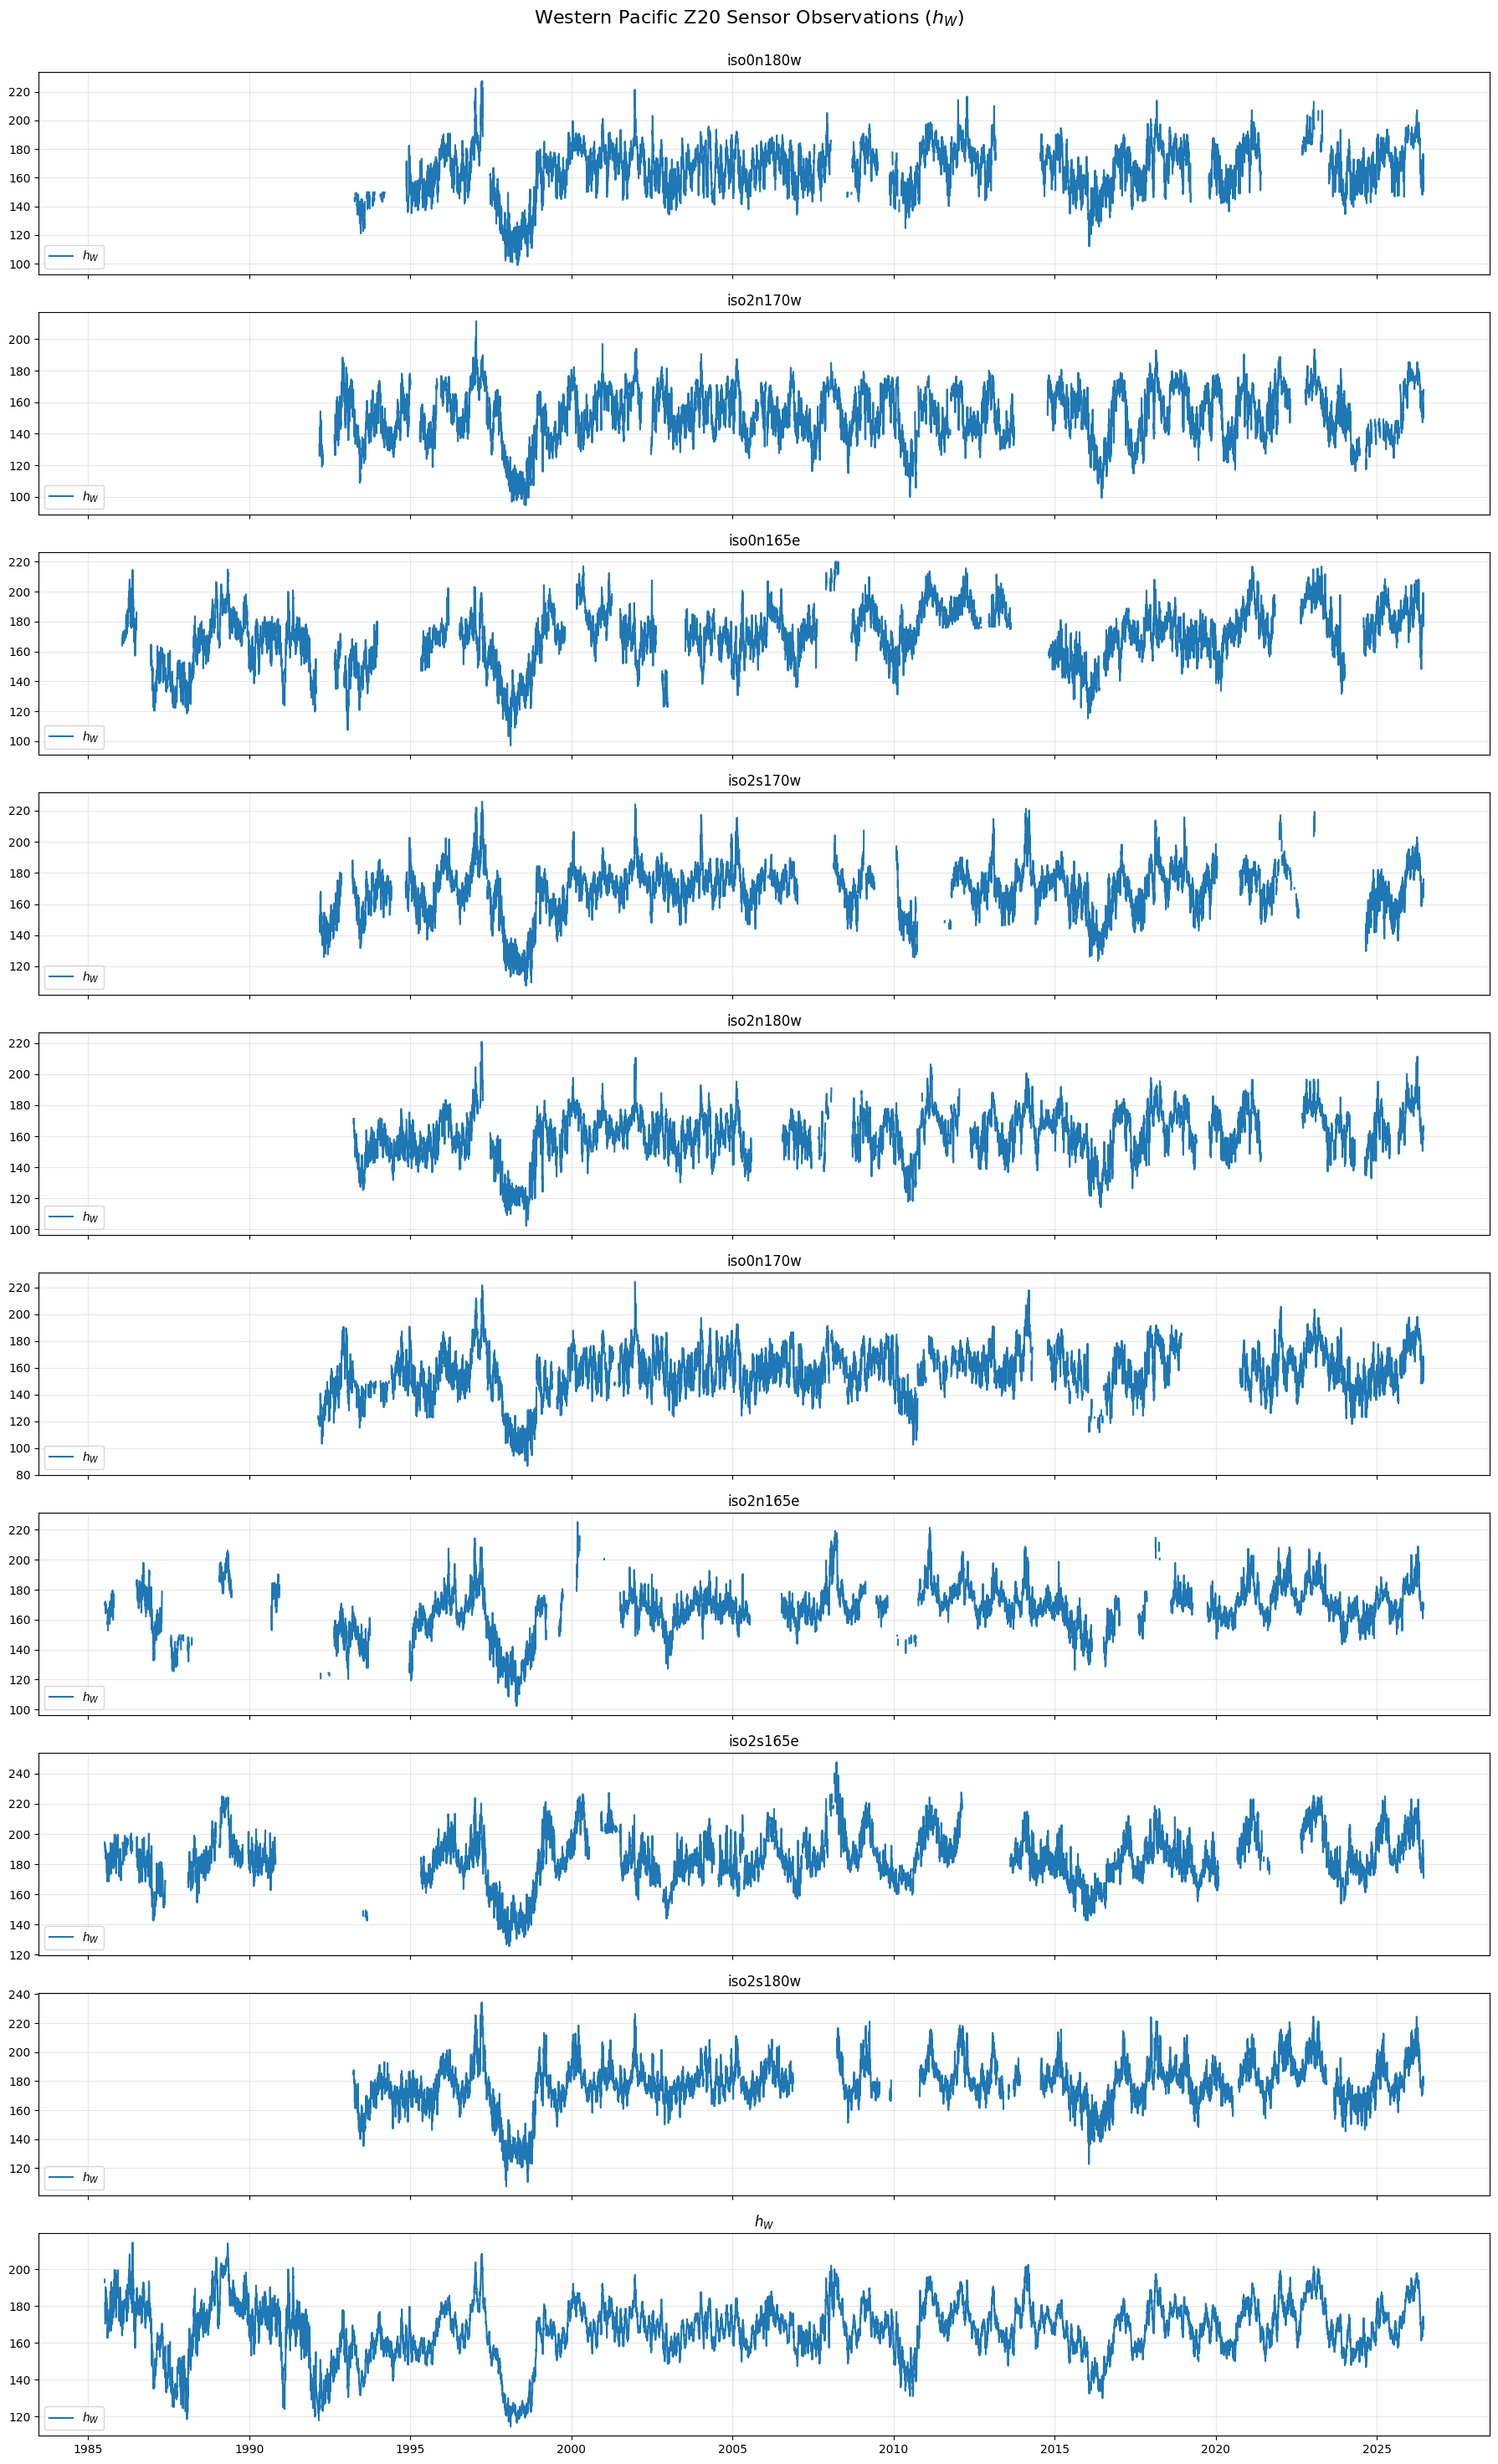

In [18]:
fig, axes = plt.subplots(
    len(west_h_df.columns)-1, 1,
    figsize=(18, 3*(len(west_h_df.columns)-1)),
    sharex=True
)

for ax, col in zip(axes, west_h_df.columns[1:]):

    title = r"$h_W$" if col == "z20_mean" else col

    ax.plot(
        west_h_df["date"],
        west_h_df[col],
        color="tab:blue",
        label=r"$h_W$"
    )

    ax.set_title(title)

    ax.legend(loc="lower left")

    ax.grid(alpha=0.3)

fig.suptitle(
    r"Western Pacific Z20 Sensor Observations ($h_W$)",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig(
    IMAGE_DIR / "west_h_sensors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

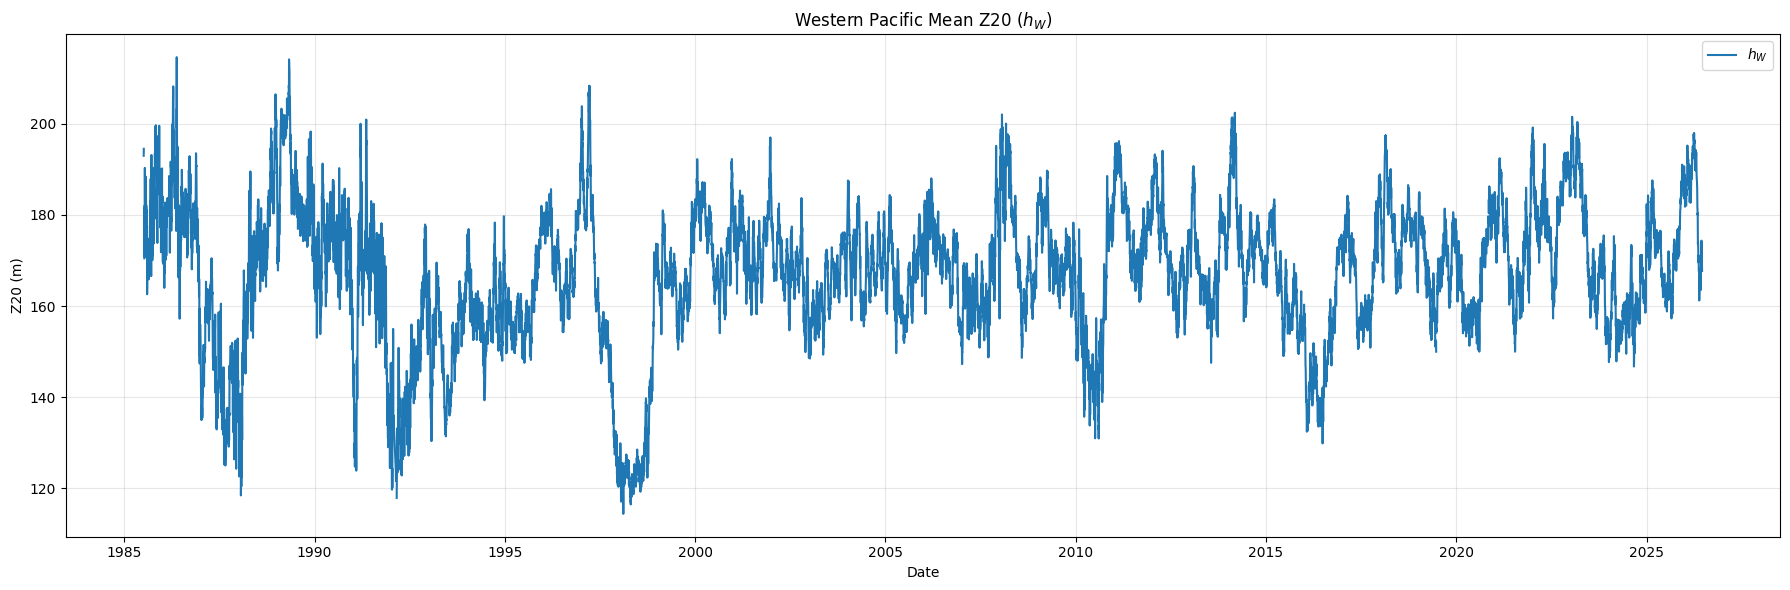

In [19]:
plt.figure(figsize=(18, 6))

plt.plot(
    west_h_df["date"],
    west_h_df["z20_mean"],
    color="tab:blue",
    linewidth=1.5,
    label=r"$h_W$"
)

plt.title(r"Western Pacific Mean Z20 ($h_W$)")
plt.xlabel("Date")
plt.ylabel("Z20 (m)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "west_h_mean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
enso_dataset = (
    west_sst_df[["date", "sst_mean"]]
    .rename(columns={"sst_mean": "west_t"})
    .merge(
        west_h_df[["date", "z20_mean"]]
        .rename(columns={"z20_mean": "west_h"}),
        on="date",
        how="outer"
    )
    .merge(
        east_sst_df[["date", "sst_mean"]]
        .rename(columns={"sst_mean": "east_t"}),
        on="date",
        how="outer"
    )
    .merge(
        east_h_df[["date", "z20_mean"]]
        .rename(columns={"z20_mean": "east_h"}),
        on="date",
        how="outer"
    )
    .sort_values("date")
    .reset_index(drop=True)
)

PROCESS = DATA / "processed"

PROCESS.mkdir(parents=True, exist_ok=True)

enso_dataset.to_csv(
    PROCESS / "enso_dataset.csv",
    index=False
)

enso_dataset.head()

,date,west_t,west_h,east_t,east_h
0,1979-01-20,NaN,NaN,23.793333,70.136667
1,1979-01-21,NaN,NaN,23.936667,65.733333
2,1979-01-22,NaN,NaN,24.056667,63.583333
3,1979-01-23,NaN,NaN,23.810000,62.170000
4,1979-01-24,NaN,NaN,24.003333,67.836667


NameError: name 'final_df' is not defined

<Figure size 1800x600 with 0 Axes>

In [ ]:
plt.figure(figsize=(18, 6))

styles = {
    "east_h": {
        "color": "blue",
        "linestyle": "--"
    },
    "west_h": {
        "color": "darkblue",
        "linestyle": "-"
    }
}

labels = {
    "east_h": r"$h_E$",
    "west_h": r"$h_W$"
}

for col in ["east_h", "west_h"]:

    plt.plot(
        final_df["date"],
        final_df[col],
        color=styles[col]["color"],
        linestyle=styles[col]["linestyle"],
        linewidth=1.5,
        label=labels[col]
    )

plt.title("Eastern and Western Pacific Z20")

plt.xlabel("Date")
plt.ylabel("Z20 (m)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "east_west_h.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8)
)

settings = {
    "west_t": {"label": r"$T_W$", "color": "darkorange"},
    "west_h": {"label": r"$h_W$", "color": "darkblue"},
    "east_t": {"label": r"$T_E$", "color": "orange"},
    "east_h": {"label": r"$h_E$", "color": "blue"}
}

for ax, col in zip(axes.flatten(), final_df.columns[1:]):

    ax.hist(
        final_df[col].dropna(),
        bins=30,
        density=True,
        color=settings[col]["color"],
        alpha=0.8
    )

    ax.set_title(settings[col]["label"])

    ax.set_ylabel("Density")

    ax.grid(alpha=0.3)

fig.suptitle(
    "Distribution of ENSO Variables",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    IMAGE_DIR / "distribution_enso.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
def plot_scatter(df):

    fig, ax = plt.subplots(
        1, 2,
        figsize=(12,5)
    )

    corr3 = df["nino3_sst"].corr(
        df["nino3_z20"]
    )

    ax[0].scatter(
        df["nino3_z20"],
        df["nino3_sst"],
        alpha=0.4
    )

    ax[0].set_title(
        f"Nino3 (r={corr3:.2f})"
    )

    ax[0].set_xlabel("Z20 (m)")
    ax[0].set_ylabel("SST (°C)")

    ax[0].grid(alpha=0.3)


    corr4 = df["nino4_sst"].corr(
        df["nino4_z20"]
    )

    ax[1].scatter(
        df["nino4_z20"],
        df["nino4_sst"],
        alpha=0.4
    )

    ax[1].set_title(
        f"Nino4 (r={corr4:.2f})"
    )

    ax[1].set_xlabel("Z20 (m)")
    ax[1].set_ylabel("SST (°C)")

    ax[1].grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

    print(f"Nino3 correlation : {corr3:.3f}")

    print(f"Nino4 correlation : {corr4:.3f}")

plot_scatter(final_df)

In [ ]:
def lag_analysis(df, sst_col, z20_col, max_lag=400):

    lags = range(-max_lag, max_lag+1)

    corrs = [
        df[sst_col].corr(
            df[z20_col].shift(lag)
        )
        for lag in lags
    ]

    best_idx = np.nanargmax(corrs)

    best_lag = lags[best_idx]

    best_corr = corrs[best_idx]

    plt.figure(figsize=(8,4))

    plt.plot(lags, corrs)

    plt.axvline(
        best_lag,
        color="red",
        linestyle="--",
        label=f"Peak lag={best_lag}"
    )

    plt.axhline(
        0,
        color="black",
        linestyle=":"
    )

    plt.xlabel("Lag (days)")

    plt.ylabel("Correlation")

    plt.title(f"{sst_col} vs {z20_col}")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

    print(f"Best lag : {best_lag}")

    print(f"Best correlation : {best_corr:.3f}")

    return best_lag, best_corr

In [ ]:
lag_analysis(final_df, "nino3_sst", "nino3_z20")


In [ ]:
lag_analysis(final_df, "nino4_sst", "nino4_z20")

In [ ]:
def spectral_analysis(series, name):

    freqs, power = periodogram(
        series,
        fs=1
    )

    plt.figure(figsize=(9,4))

    plt.plot(
        1/freqs[1:],
        power[1:],
        linewidth=1.5
    )

    plt.xlim(0,3000)

    plt.xlabel("Period (days)")

    plt.ylabel("Power")

    plt.title(f"Power Spectrum of {name}")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

    peaks, _ = find_peaks(power)

    top = pd.DataFrame({
        "period_days": 1/freqs[peaks],
        "power": power[peaks]
    })

    return top.sort_values(
        "power",
        ascending=False
    ).head(10)

In [ ]:
nino3_sst_spec = spectral_analysis(
    final_df["nino3_sst"].dropna(),
    "Nino3 SST"
)

nino4_sst_spec = spectral_analysis(
    final_df["nino4_sst"].dropna(),
    "Nino4 SST"
)

nino3_z20_spec = spectral_analysis(
    final_df["nino3_z20"].dropna(),
    "Nino3 Z20"
)

nino4_z20_spec = spectral_analysis(
    final_df["nino4_z20"].dropna(),
    "Nino4 Z20"
)